In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np 
import warnings 
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import  to_categorical
from tensorflow.keras.models import load_model


In [34]:
df= pd.read_csv(r'D:\deep_learning\DATA\MNIST_DATA\train.csv.zip')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
df.shape

(42000, 785)

In [5]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
X = df.drop("label", axis=1).values
y = df["label"].values

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [8]:
X_train = df.drop("label", axis=1).values
y_train = df["label"].values
X_test = df.drop("label", axis=1).values
y_test = df["label"].values

In [9]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [10]:
X_train_img = X_train.reshape(-1, 28, 28)
X_test_img = X_test.reshape(-1, 28, 28)

In [11]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [12]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

2026-09-05 07:09:51.223242: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [36]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [15]:
history_percp = perceptron.fit(X_train_img, y_train_cat, epochs=10, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8854 - loss: 0.4309 - val_accuracy: 0.8899 - val_loss: 0.4107
Epoch 2/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8916 - loss: 0.3985 - val_accuracy: 0.8949 - val_loss: 0.3857
Epoch 3/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8961 - loss: 0.3782 - val_accuracy: 0.8980 - val_loss: 0.3689
Epoch 4/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8995 - loss: 0.3637 - val_accuracy: 0.9019 - val_loss: 0.3565
Epoch 5/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9022 - loss: 0.3529 - val_accuracy: 0.9036 - val_loss: 0.3470
Epoch 6/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9045 - loss: 0.3443 - val_accuracy: 0.9058 - val_loss: 0.3392
Epoch 7/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9062 - loss: 0.3372 - val_accuracy: 0.9074 - val_loss: 0.3328
Epoch 8/10
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9076 - loss: 0.3312 - 

In [17]:
perceptron.save("perceptron_model.keras")


In [18]:
perp_model = load_model('perceptron_model.keras')

In [19]:
acc_percp = perp_model.evaluate(X_test_img, y_test_cat, verbose=1)[1]
acc_percp

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9115 - loss: 0.3184


0.9114523530006409

ann


In [37]:
ann_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

In [21]:
ann_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [22]:
history_ann = ann_model.fit(X_train_img, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_img, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9175 - loss: 0.2751 - val_accuracy: 0.9610 - val_loss: 0.1300
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9657 - loss: 0.1136 - val_accuracy: 0.9774 - val_loss: 0.0767
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9763 - loss: 0.0775 - val_accuracy: 0.9841 - val_loss: 0.0511
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9812 - loss: 0.0575 - val_accuracy: 0.9884 - val_loss: 0.0381
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9855 - loss: 0.0447 - val_accuracy: 0.9809 - val_loss: 0.0564


In [23]:
ann_model.save("ann_model.keras")

In [38]:
ann_model=load_model('ann_model.keras')

In [25]:
acc_ann = ann_model.evaluate(X_test_img, y_test_cat, verbose=0)[1]
acc_ann

0.9809285998344421

cnn

In [26]:
X_train_cnn = X_train.reshape(-1, 28, 28,1)
X_test_cnn = X_test.reshape(-1, 28, 28, 1)

In [27]:
cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation="relu", input_shape=(28,28,1)),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation="relu"),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [28]:
cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [29]:
history_cnn = cnn_model.fit(X_train_cnn, y_train_cat, epochs=5, batch_size=32, validation_data=(X_test_cnn, y_test_cat), verbose=1)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 28s 20ms/step - accuracy: 0.9268 - loss: 0.2409 - val_accuracy: 0.9830 - val_loss: 0.0532
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9730 - loss: 0.0865 - val_accuracy: 0.9903 - val_loss: 0.0311
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9810 - loss: 0.0638 - val_accuracy: 0.9925 - val_loss: 0.0252
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9846 - loss: 0.0516 - val_accuracy: 0.9934 - val_loss: 0.0200
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 26s 20ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9948 - val_loss: 0.0157


In [39]:
cnn_model.save("cnn_model.keras")

In [40]:
cnn_model=load_model('cnn_model.keras')

In [41]:
acc_cnn = cnn_model.evaluate(X_test_img, y_test_cat, verbose=1)[1]
acc_cnn

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9948 - loss: 0.0157


0.9948095083236694

In [43]:
print(acc_cnn) 
print(acc_ann)
print(acc_percp)

0.9948095083236694
0.9892857074737549
0.9144999980926514


In [51]:
def plot_training(model, title):
    # Reshape flattened MNIST data to 28x28
    X_train_img = X_train.reshape(-1, 28, 28)
    X_test_img = X_test.reshape(-1, 28, 28)

    # Convert integer labels to one-hot encoding
    y_train_cat = to_categorical(y_train, num_classes=10)
    y_test_cat = to_categorical(y_test, num_classes=10)

    # Evaluate loaded model
    train_loss, train_acc = model.evaluate(
        X_train_img, y_train_cat, verbose=0
    )

    test_loss, test_acc = model.evaluate(
        X_test_img, y_test_cat, verbose=0
    )

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.bar(["Train", "Test"], [train_acc, test_acc])
    plt.title(f"{title} Accuracy")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)

    # Loss
    plt.subplot(1, 2, 2)
    plt.bar(["Train", "Test"], [train_loss, test_loss])
    plt.title(f"{title} Loss")
    plt.ylabel("Loss")

    plt.tight_layout()
    plt.show()

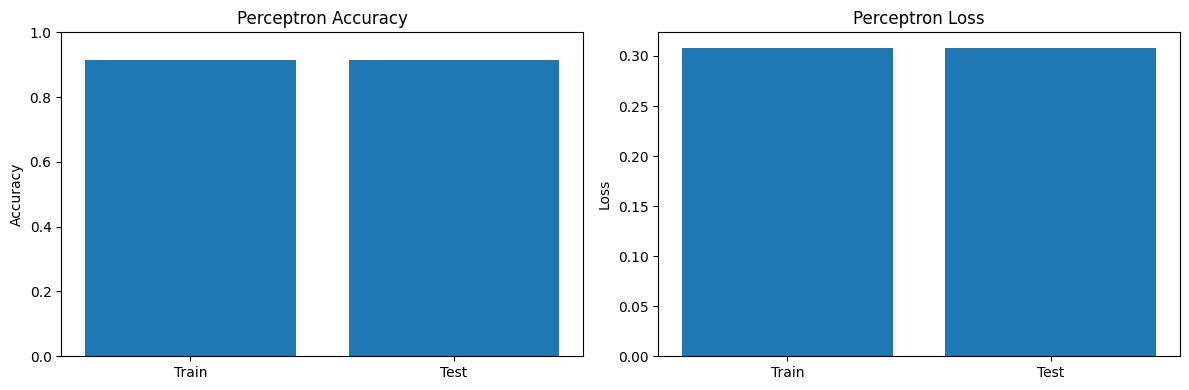

In [52]:
plot_training(perp_model, "Perceptron")

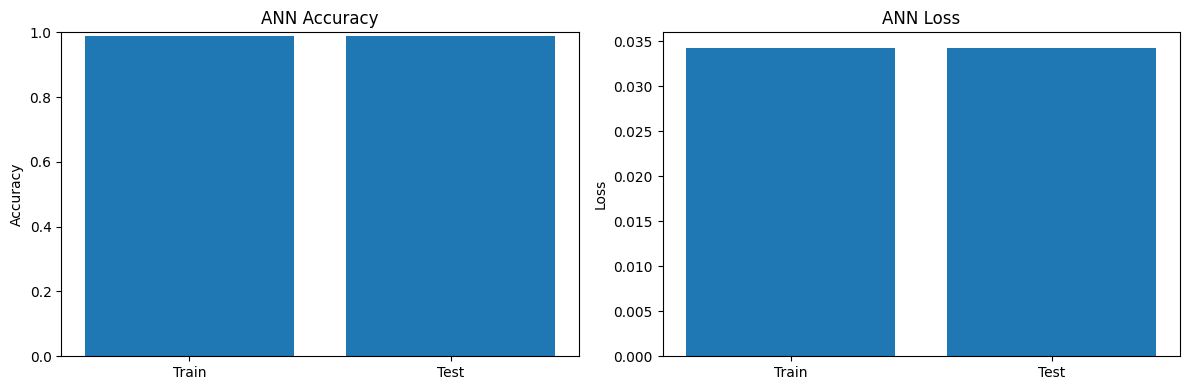

In [53]:
plot_training(ann_model, "ANN")

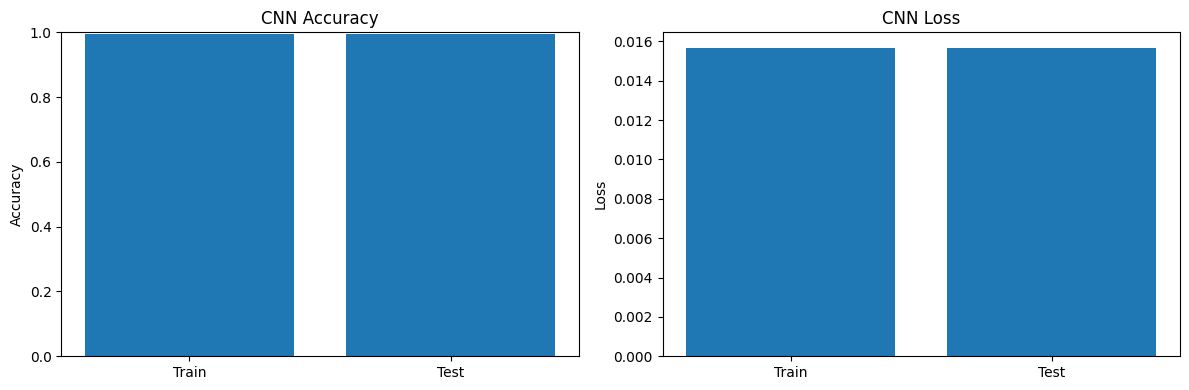

In [56]:
plot_training(cnn_model, "CNN")

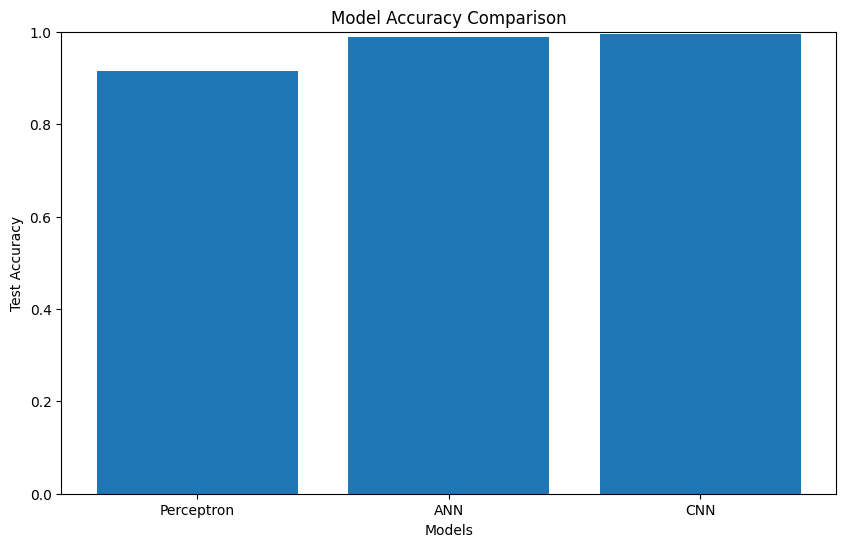

In [59]:
plt.figure(figsize=(10, 6))

plt.bar(
    ["Perceptron", "ANN", "CNN"],
    [acc_percp, acc_ann, acc_cnn]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

plt.show()

In [60]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━

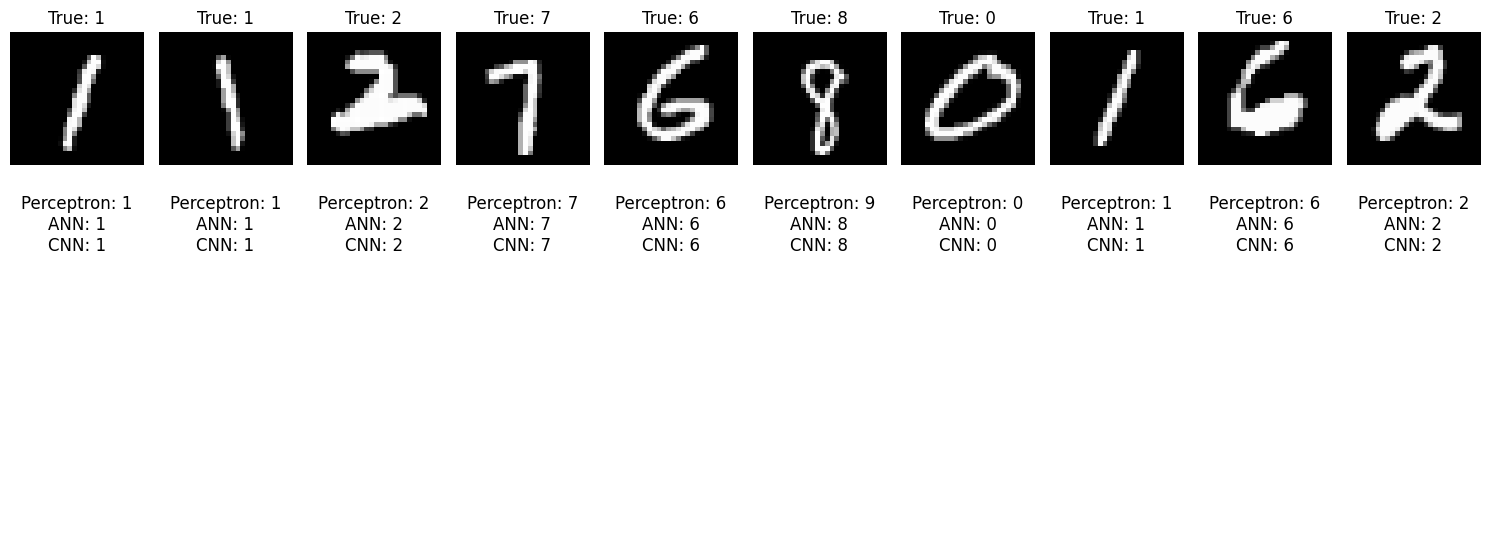

In [62]:
show_side_by_side([perp_model, ann_model, cnn_model], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 10)